# Sentiment Exploration — Polygon `/v2/reference/news` + FinBERT

Inspect sentiment data at every stage of the pipeline:
raw Polygon API → insight aggregation → on-disk files → processed → features.

Change `TICKER` and `FETCH_DATE` in Cell 1 and re-run any cell independently.

In [36]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))   # repo root

from datetime import date, timedelta
from pprint import pprint

import pandas as pd
from dotenv import load_dotenv
import os

load_dotenv('../.env')

True

In [37]:
# ── Cell 1: Config — edit these ──────────────────────────────────────────────
TICKER     = "NVDA"          # ticker to test
FETCH_DATE = "2026-04-29"    # YYYY-MM-DD

# ── Setup ────────────────────────────────────────────────────────────────────
POLYGON_KEY = os.environ.get('POLYGON_API_KEY', '')
if not POLYGON_KEY:
    print('WARNING: POLYGON_API_KEY not found in .env')
else:
    print(f'API key loaded ({len(POLYGON_KEY)} chars)')

FETCH_DATE_OBJ = date.fromisoformat(FETCH_DATE)
RAW_SENT_DIR   = Path('../data/raw/sentiment')
PROC_DIR       = Path('../data/processed')
FEAT_DIR       = Path('../data/features')
print(f'Target: {TICKER} on {FETCH_DATE}')

API key loaded (32 chars)
Target: NVDA on 2026-04-29


## 1. Raw API response — what does Polygon `/v2/reference/news` return?

Each article in `results[]` has an `insights[]` array with per-ticker entries:
- `ticker`: e.g. `"NVDA"`
- `sentiment`: `"positive"` / `"negative"` / `"neutral"` (Polygon pre-computed)
- `sentiment_reasoning`: free-text explanation used as FinBERT input

In [38]:
from src.ingestion.rate_limiter import RateLimiter
from src.ingestion.clients.polygon import PolygonClient

fast_limiter = RateLimiter(calls_per_minute=999)
client = PolygonClient(api_key=POLYGON_KEY, rate_limiter=fast_limiter)

date_from = (FETCH_DATE_OBJ - timedelta(days=1)).strftime("%Y-%m-%dT00:00:00Z")
date_to   = FETCH_DATE_OBJ.strftime("%Y-%m-%dT23:59:59Z")
articles  = client._fetch_news_pages(TICKER, date_from, date_to)

print(f'Total articles in window: {len(articles)}')
if articles:
    print(f'Article keys: {list(articles[0].keys())}')
    for art in articles:
        matches = [i for i in (art.get('insights') or []) if (i.get('ticker') or '').upper() == TICKER.upper()]
        if matches:
            print(f'\nFirst article with {TICKER} insight:')
            print(f'  title: {art.get("title", "")[:80]}')
            print(f'  published_utc: {art.get("published_utc", "")}')
            print(f'\n  Insight entry for {TICKER}:')
            pprint(matches[0])
            break
    else:
        print(f'No articles with {TICKER} insights found in window')

Total articles in window: 26
Article keys: ['id', 'publisher', 'title', 'author', 'published_utc', 'article_url', 'tickers', 'image_url', 'description', 'keywords', 'insights']

First article with NVDA insight:
  title: NVIDIA Sets Conference Call for First-Quarter Financial Results
  published_utc: 2026-04-29T21:00:00Z

  Insight entry for NVDA:
{'sentiment': 'positive',
 'sentiment_reasoning': 'NVIDIA is expanding its AI ecosystem through '
                        'strategic partnerships (Marvell), launching advanced '
                        'AI models (Ising) for quantum computing, and '
                        'maintaining its position as a leader in AI and '
                        'accelerated computing. These developments indicate '
                        'growth and market expansion.',
 'ticker': 'NVDA'}


## 2. All insights for this ticker — Polygon labels article by article

In [39]:
rows = []
for article in articles:
    for insight in (article.get('insights') or []):
        if (insight.get('ticker') or '').upper() != TICKER.upper():
            continue
        rows.append({
            'title':             article.get('title', '')[:60],
            'published_utc':     article.get('published_utc', ''),
            'polygon_sentiment': insight.get('sentiment', ''),
            'reasoning':         (insight.get('sentiment_reasoning') or '')[:80],
        })

feed_df = pd.DataFrame(rows)
if feed_df.empty:
    print(f'No insights found for {TICKER} in this window')
else:
    print(f'{len(feed_df)} insights for {TICKER}')
    print(feed_df['polygon_sentiment'].value_counts().to_string())
    print()
    display(feed_df)

26 insights for NVDA
polygon_sentiment
positive    13
neutral     10
negative     3



,title,published_utc,polygon_sentiment,reasoning
0,NVIDIA Sets Conference Call for First-Quarter ...,2026-04-29T21:00:00Z,positive,NVIDIA is expanding its AI ecosystem through s...
1,The Best Growth Stocks to Buy Right Now,2026-04-29T20:10:00Z,neutral,Mentioned as a supplier of GPUs to CoreWeave a...
2,4 Stocks Primed to Benefit From the $7 Trillio...,2026-04-29T20:04:00Z,positive,Largest company globally with massive demand f...
3,Higher Yield or Long-Term Dividend Growth? FDV...,2026-04-29T18:04:54Z,neutral,Mentioned as a top holding in FDVV with signif...
4,AMD’s Poker Face: Reading the Tell in a Panic-...,2026-04-29T16:54:00Z,neutral,NVIDIA is mentioned as a competitor whose domi...
5,"Gorilla Technology To Deploy 20,736 GPUs In In...",2026-04-29T15:33:47Z,positive,NVIDIA's HGX B200 servers are central to the d...
6,"Which Is the Better Dividend ETF, Fidelity's F...",2026-04-29T14:30:03Z,neutral,Highlighted as FDVV's largest position (6.73%)...
7,Intel CEO Lip-Bu Tan Just Delivered Phenomenal...,2026-04-29T13:20:00Z,neutral,Mentioned as a dominant GPU competitor with su...
8,What's Going On With Nvidia Stock Today?,2026-04-29T13:12:40Z,positive,Launched advanced multimodal AI model with sup...
9,Will S&P 500 Open Up Or Down On April 29?,2026-04-29T08:50:33Z,negative,Down 0.15%; specifically mentioned as impacted...


## 3. FinBERT scoring — what the pipeline computes per insight

FinBERT (`ProsusAI/finbert`) runs on each `sentiment_reasoning` string.  
When reasoning is absent, Polygon's own label is used with `confidence=0.5`.

`company_news_score = Σ(sign × confidence) / n_insights`, clamped to [−1, 1]

In [40]:
# Set USE_FINBERT=False to skip the model and use Polygon labels only (faster)
USE_FINBERT = True

finbert = None
if USE_FINBERT:
    try:
        from transformers import pipeline as hf_pipeline
        finbert = hf_pipeline(
            'text-classification', model='ProsusAI/finbert',
            device=-1, truncation=True, max_length=512,
        )
        print('FinBERT loaded')
    except Exception as e:
        print(f'FinBERT unavailable ({e}) — will use Polygon labels at confidence=0.5')
else:
    print('FinBERT skipped — using Polygon labels only')

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 21080.07it/s]


FinBERT loaded


In [41]:
_SIGN = {'positive': 1.0, 'negative': -1.0, 'neutral': 0.0}

scored_rows = []
for article in articles:
    for insight in (article.get('insights') or []):
        if (insight.get('ticker') or '').upper() != TICKER.upper():
            continue
        polygon_label = (insight.get('sentiment') or 'neutral').lower()
        reasoning     = (insight.get('sentiment_reasoning') or '').strip()

        if reasoning and finbert is not None:
            result     = finbert(reasoning[:512])[0]
            fb_label   = result['label'].lower()
            confidence = float(result['score'])
        else:
            fb_label   = polygon_label
            confidence = 0.5

        scored_rows.append({
            'polygon_label':  polygon_label,
            'finbert_label':  fb_label,
            'confidence':     round(confidence, 4),
            'contribution':   round(_SIGN.get(fb_label, 0.0) * confidence, 4),
            'reasoning':      reasoning[:70] or '(no reasoning text)',
        })

if scored_rows:
    scored_df = pd.DataFrame(scored_rows)
    total     = len(scored_rows)
    score     = max(-1.0, min(1.0, round(scored_df['contribution'].sum() / total, 4)))
    print(f'company_news_score = {score}  (n_insights={total})')
    display(scored_df)
else:
    print(f'No insights to score for {TICKER}')

company_news_score = 0.3442  (n_insights=26)


,polygon_label,finbert_label,confidence,contribution,reasoning
0,positive,positive,0.9353,0.9353,NVIDIA is expanding its AI ecosystem through s...
1,neutral,neutral,0.8955,0.0000,Mentioned as a supplier of GPUs to CoreWeave a...
2,positive,positive,0.9360,0.9360,Largest company globally with massive demand f...
3,neutral,positive,0.7891,0.7891,Mentioned as a top holding in FDVV with signif...
4,neutral,negative,0.8879,-0.8879,NVIDIA is mentioned as a competitor whose domi...
5,positive,positive,0.9326,0.9326,NVIDIA's HGX B200 servers are central to the d...
6,neutral,negative,0.5637,-0.5637,Highlighted as FDVV's largest position (6.73%)...
7,neutral,positive,0.8736,0.8736,Mentioned as a dominant GPU competitor with su...
8,positive,positive,0.9416,0.9416,Launched advanced multimodal AI model with sup...
9,negative,negative,0.9749,-0.9749,Down 0.15%; specifically mentioned as impacted...


## 4. Aggregated SentimentRecord — what the pipeline writes to disk

In [42]:
record = client._aggregate_insights(TICKER, FETCH_DATE_OBJ, articles, finbert)

print(f'SentimentRecord for {TICKER} on {FETCH_DATE}:')
print(f'  bullish_percent:    {record.bullish_percent}')
print(f'  bearish_percent:    {record.bearish_percent}')
print(f'  company_news_score: {record.company_news_score}')
print(f'  article_count:      {record.article_count}')
print(f'  positive_insights:  {record.positive_insights}')
print(f'  negative_insights:  {record.negative_insights}')
print(f'  neutral_insights:   {record.neutral_insights}')
print()
all_null = all(v is None for v in [
    record.bullish_percent, record.bearish_percent,
    record.company_news_score, record.article_count,
])
print(f'Pipeline status: {"NULL (no insights for ticker)" if all_null else "OK"}')

SentimentRecord for NVDA on 2026-04-29:
  bullish_percent:    0.5
  bearish_percent:    0.1154
  company_news_score: 0.3442
  article_count:      26.0
  positive_insights:  13
  negative_insights:  3
  neutral_insights:   10

Pipeline status: OK


## 5. On-disk inventory — which tickers have sentiment files and data

In [43]:
inventory = []
for ticker_dir in sorted(RAW_SENT_DIR.iterdir()):
    if not ticker_dir.is_dir():
        continue
    for f in sorted(ticker_dir.glob('*.csv')):
        try:
            df = pd.read_csv(f)
            has_data = not df.empty and df['company_news_score'].notna().any()
            status = 'data' if has_data else 'null'
        except Exception as e:
            status = f'error: {e}'
        inventory.append({'ticker': ticker_dir.name, 'date': f.stem, 'status': status})

inv_df = pd.DataFrame(inventory)
if inv_df.empty:
    print('No sentiment files on disk yet — run make nightly first')
else:
    summary = inv_df.groupby('status').size().rename('count')
    print('On-disk sentiment files:')
    display(summary)
    print(f'\nTickers with at least one data file: {inv_df[inv_df["status"]=="data"]["ticker"].nunique()}')
    display(inv_df)

On-disk sentiment files:


status
data    117
null    175
Name: count, dtype: int64


Tickers with at least one data file: 29


,ticker,date,status
0,AAL,2026-04-23,null
1,AAL,2026-04-24,null
2,AAPL,2026-04-23,null
3,AAPL,2026-04-28,data
4,AAPL,2026-04-29,data
...,...,...,...
287,TZA,2026-04-25,null
288,UVIX,2026-04-24,null
289,WIMI,2026-04-24,null
290,WU,2026-04-24,data


## 6. Coverage heatmap — which tickers have data on which dates

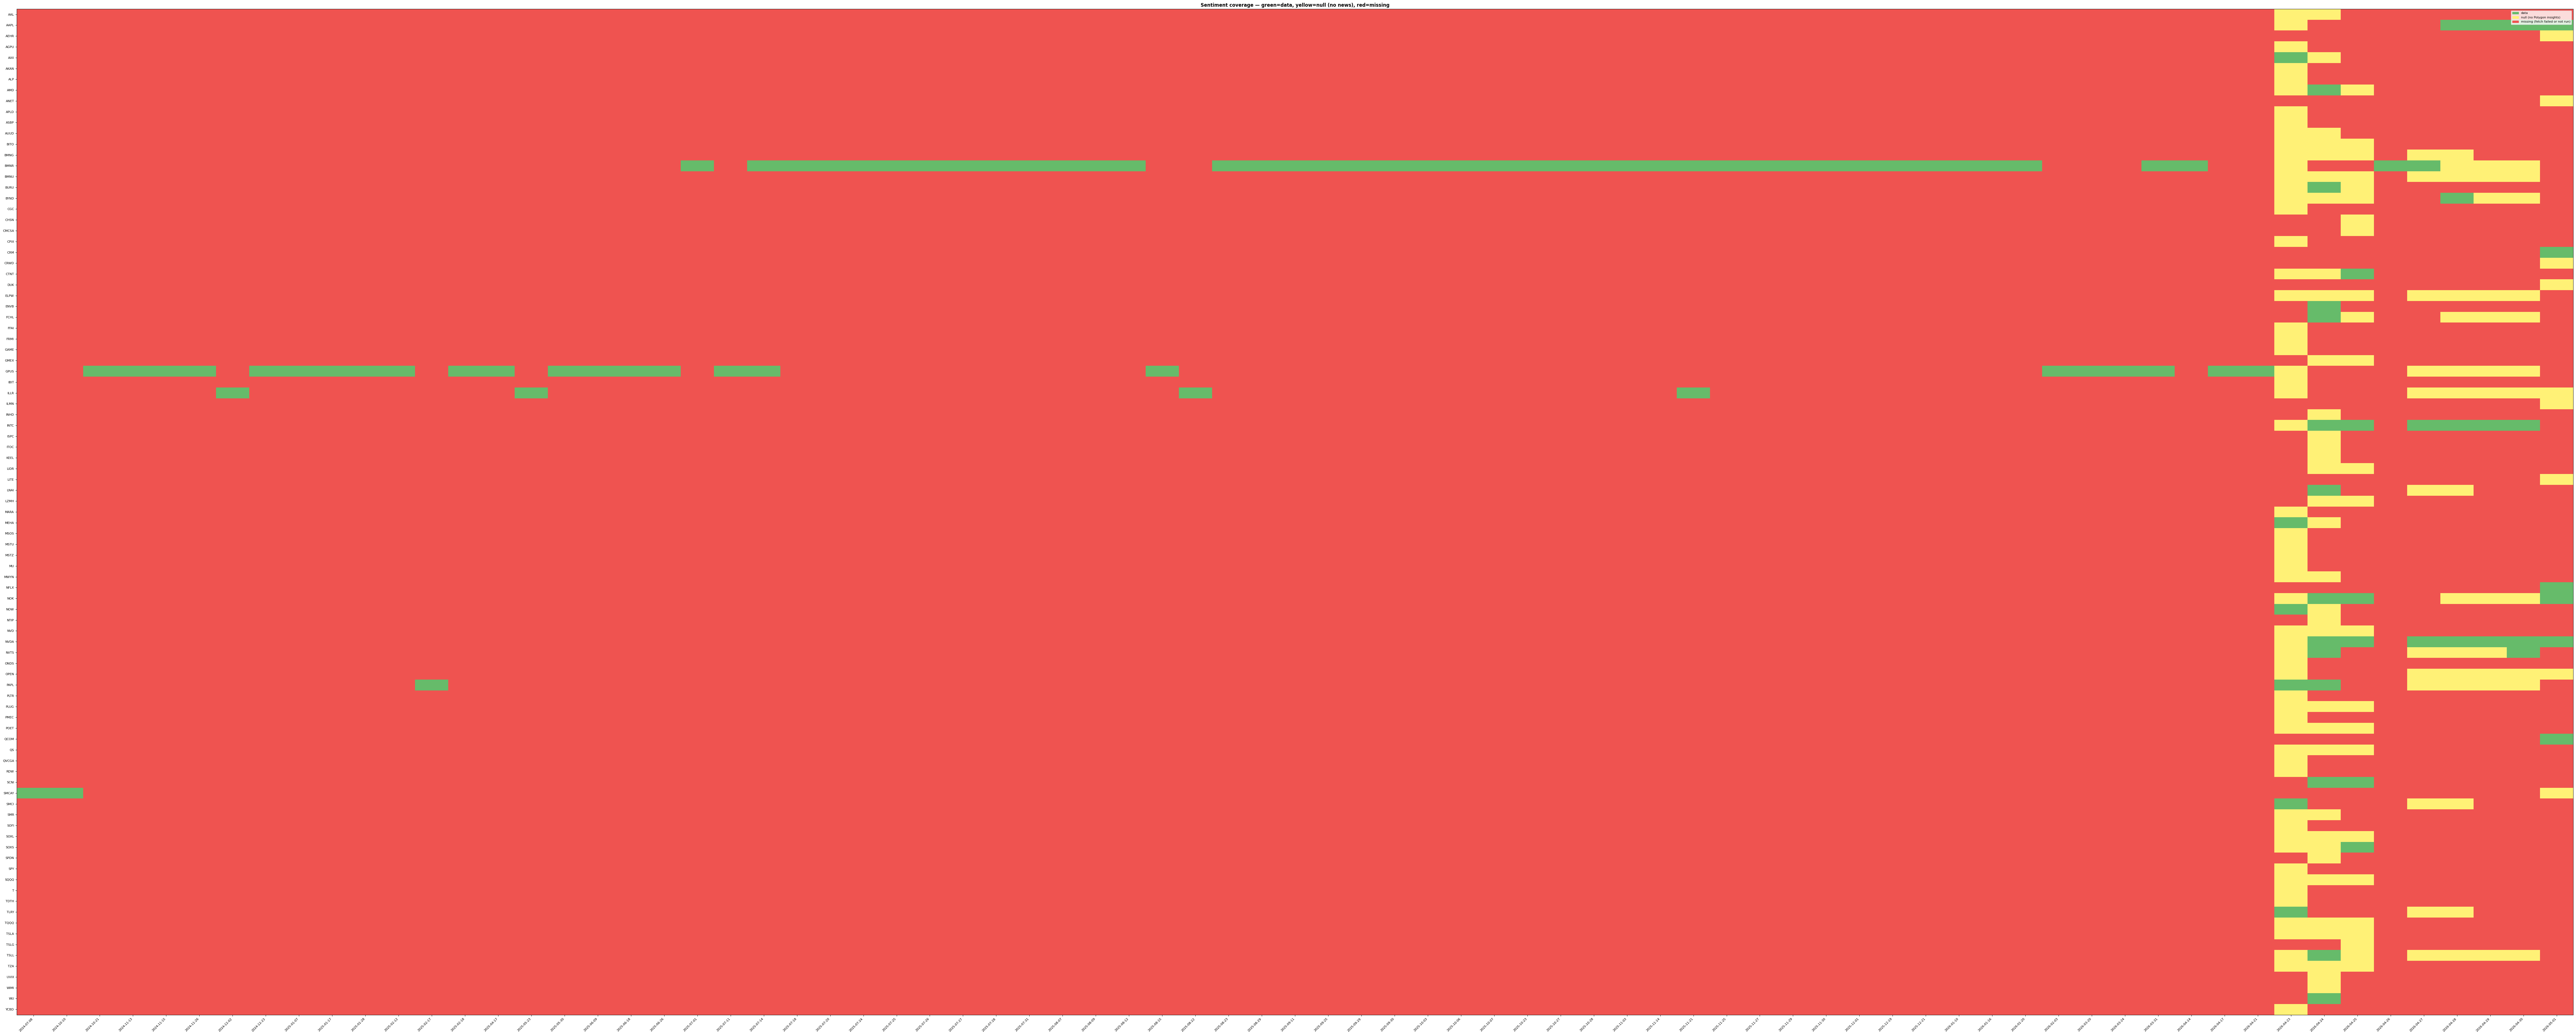

In [44]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

if inv_df.empty:
    print('No sentiment files on disk — run make nightly first')
else:
    pivot = inv_df.pivot(index='ticker', columns='date', values='status').fillna('missing')
    status_to_num = {'data': 1, 'null': 0, 'missing': -1}
    num_pivot = pivot.map(lambda s: status_to_num.get(s if isinstance(s, str) else 'missing', -1))

    fig, ax = plt.subplots(figsize=(max(6, len(pivot.columns) * 1.2), max(4, len(pivot) * 0.4)))
    ax.imshow(num_pivot.values, cmap=ListedColormap(['#EF5350', '#FFF176', '#66BB6A']),
              vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=8)
    ax.set_title('Sentiment coverage — green=data, yellow=null (no news), red=missing', fontweight='bold')
    ax.legend(handles=[
        Patch(color='#66BB6A', label='data'),
        Patch(color='#FFF176', label='null (no Polygon insights)'),
        Patch(color='#EF5350', label='missing (fetch failed or not run)'),
    ], loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()

## 7. Pipeline trace — does sentiment make it through to features?

In [45]:
SENTIMENT_COLS = [
    'bullish_percent', 'bearish_percent', 'company_news_score',
    'article_count', 'positive_insights', 'negative_insights',
    'neutral_insights', 'sentiment_available',
]

def load_latest(directory, ticker, label):
    ticker_dir = directory / ticker
    if not ticker_dir.exists():
        print(f'  [{label}] no directory for {ticker}')
        return None
    files = sorted(ticker_dir.glob('*.csv'))
    if not files:
        print(f'  [{label}] no CSV files for {ticker}')
        return None
    df = pd.read_csv(files[-1])
    present = [c for c in SENTIMENT_COLS if c in df.columns]
    print(f'  [{label}] {files[-1].name} — {len(df)} rows, sentiment cols: {present}')
    return df

print(f'Pipeline trace for {TICKER}:\n')
proc_df = load_latest(PROC_DIR, TICKER, 'processed')
feat_df = load_latest(FEAT_DIR, TICKER, 'features')

for label, df in [('processed', proc_df), ('features', feat_df)]:
    if df is None:
        continue
    if 'sentiment_available' in df.columns:
        mask = df['sentiment_available'].astype(str).str.lower().isin(['true', '1'])
        print(f'\n  [{label}] sentiment_available=True on {mask.sum()}/{len(df)} rows')
        if mask.sum():
            cols = ['date'] + [c for c in SENTIMENT_COLS if c in df.columns]
            print(df[mask][cols].tail(5).to_string(index=False))

Pipeline trace for NVDA:

  [processed] 2026-05-01.csv — 501 rows, sentiment cols: ['bullish_percent', 'bearish_percent', 'company_news_score', 'article_count', 'positive_insights', 'negative_insights', 'neutral_insights', 'sentiment_available']
  [features] 2026-05-01.csv — 436 rows, sentiment cols: ['bullish_percent', 'bearish_percent', 'company_news_score', 'article_count', 'positive_insights', 'negative_insights', 'neutral_insights', 'sentiment_available']

  [processed] sentiment_available=True on 1/501 rows
      date  bullish_percent  bearish_percent  company_news_score  article_count  positive_insights  negative_insights  neutral_insights  sentiment_available
2026-04-30           0.5455           0.2273              0.3096           22.0               12.0                5.0               5.0                 True

  [features] sentiment_available=True on 0/436 rows


## 8. Live health check — stage-by-stage for any ticker/date

In [46]:
TEST_TICKER = TICKER
TEST_DATE   = FETCH_DATE_OBJ

print(f'Health check: {TEST_TICKER} on {TEST_DATE}\n')
results = {}

# Stage 1: API fetch
try:
    _from = (TEST_DATE - timedelta(days=1)).strftime("%Y-%m-%dT00:00:00Z")
    _to   = TEST_DATE.strftime("%Y-%m-%dT23:59:59Z")
    _arts = client._fetch_news_pages(TEST_TICKER, _from, _to)
    _n    = sum(1 for a in _arts for i in (a.get('insights') or [])
                if (i.get('ticker') or '').upper() == TEST_TICKER.upper())
    results['1. API fetch'] = f'OK — {len(_arts)} articles, {_n} {TEST_TICKER} insights'
except Exception as e:
    results['1. API fetch'] = f'FAIL — {e}'
    _arts = []

# Stage 2: Aggregation
try:
    _rec  = client._aggregate_insights(TEST_TICKER, TEST_DATE, _arts, finbert)
    _null = all(v is None for v in [_rec.bullish_percent, _rec.bearish_percent,
                                     _rec.company_news_score, _rec.article_count])
    results['2. Aggregation'] = (
        'null (no insights)' if _null
        else f'OK — score={_rec.company_news_score}, articles={_rec.article_count}, '
             f'pos={_rec.positive_insights} neg={_rec.negative_insights} neu={_rec.neutral_insights}'
    )
except Exception as e:
    results['2. Aggregation'] = f'FAIL — {e}'

# Stage 3: Raw file
raw_path = RAW_SENT_DIR / TEST_TICKER / f'{TEST_DATE}.csv'
if raw_path.exists():
    _df  = pd.read_csv(raw_path)
    _has = _df['company_news_score'].notna().any() if 'company_news_score' in _df.columns else False
    results['3. Raw file'] = f'EXISTS — {"has data" if _has else "all null"}'
else:
    results['3. Raw file'] = 'MISSING — nightly not run for this date'

results['4. Processed dir'] = 'EXISTS' if (PROC_DIR / TEST_TICKER).exists() else 'MISSING'
results['5. Features dir']  = 'EXISTS' if (FEAT_DIR / TEST_TICKER).exists() else 'MISSING'

print('Stage results:')
for stage, result in results.items():
    icon = ('✓' if result.startswith('OK') or result.startswith('EXISTS')
            else '~' if 'null' in result.lower() or 'MISSING' in result
            else '✗')
    print(f'  {icon} {stage}: {result}')

Health check: NVDA on 2026-04-29

Stage results:
  ✓ 1. API fetch: OK — 26 articles, 26 NVDA insights
  ✓ 2. Aggregation: OK — score=0.3442, articles=26.0, pos=13 neg=3 neu=10
  ✓ 3. Raw file: EXISTS — has data
  ✓ 4. Processed dir: EXISTS
  ✓ 5. Features dir: EXISTS
